In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_2009_2010=pd.read_excel(r"E:\SEM 8\Sales_Intelligence_System\Datasets\Online Retail Dataset\online_retail_II.xlsx", sheet_name="Year 2009-2010")
data_2010_2011=pd.read_excel(r"E:\SEM 8\Sales_Intelligence_System\Datasets\Online Retail Dataset\online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [3]:
merged_data=pd.concat([data_2009_2010,data_2010_2011],ignore_index=True)

In [4]:
merged_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
merged_data.shape

(1067371, 8)

In [6]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
merged_data['Revenue']=merged_data['Quantity']*merged_data['Price']

In [8]:
merged_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [9]:
merged_data=merged_data[(merged_data['Quantity']>0)&(merged_data['Price']>0)]

In [10]:
merged_data.shape

(1041671, 9)

In [11]:
split_date=merged_data['InvoiceDate'].quantile(0.7)

In [12]:
split_date

Timestamp('2011-06-12 11:17:00')

In [13]:
training=merged_data[merged_data['InvoiceDate']<=split_date]
testing=merged_data[merged_data['InvoiceDate']>split_date]

In [14]:
training.shape,testing.shape

((729187, 9), (312484, 9))

In [15]:
clv_target=(
    testing.groupby('Customer ID')['Price'].sum().reset_index()
)
clv_target.columns=['CustomerID','FutureRevenue']

In [16]:
clv_target.head()

,CustomerID,FutureRevenue
0,12347.0,202.54
1,12348.0,42.50
2,12349.0,605.10
3,12352.0,311.03
4,12356.0,23.70


In [17]:
reference_date=training['InvoiceDate'].max()

In [18]:
reference_date

Timestamp('2011-06-12 11:17:00')

In [19]:
clv_features=training.groupby('Customer ID').agg({
    'InvoiceDate':[
        lambda x: (reference_date-x.max()).days,
        lambda x: (x.max()-x.min()).days
    ],
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

In [20]:
clv_features.columns=['CustomerID','Recency','ActiveDays','Frequency','Monetary']

In [21]:
clv_features['AverageOrderValue']=(clv_features['Monetary']/clv_features['Frequency'])

In [22]:
clv_features.head()

,CustomerID,Recency,ActiveDays,Frequency,Monetary,AverageOrderValue
0,12346.0,145,400,12,77556.46,6463.038333
1,12347.0,2,220,5,3529.27,705.854000
2,12348.0,68,189,4,1709.40,427.350000
3,12349.0,227,181,3,2671.14,890.380000
4,12350.0,129,0,1,334.40,334.400000


In [23]:
clv_features.shape

(4976, 6)

In [24]:
clv_data=pd.merge(clv_features,clv_target,on='CustomerID',how='inner')

In [25]:
clv_data.head()

,CustomerID,Recency,ActiveDays,Frequency,Monetary,AverageOrderValue,FutureRevenue
0,12347.0,2,220,5,3529.27,705.854,202.54
1,12348.0,68,189,4,1709.40,427.350,42.50
2,12349.0,227,181,3,2671.14,890.380,605.10
3,12352.0,81,130,7,1905.61,272.230,311.03
4,12356.0,64,179,5,6315.33,1263.066,23.70


In [26]:
clv_data.describe()

,CustomerID,Recency,ActiveDays,Frequency,Monetary,AverageOrderValue,FutureRevenue
count,2576.000000,2576.000000,2576.000000,2576.000000,2576.000000,2576.000000,2576.000000
mean,15335.839286,108.237189,270.432453,7.829581,3896.699154,406.152296,213.465156
std,1697.516391,110.772385,189.385455,13.164710,15091.955112,385.225941,529.416948
min,12347.000000,0.000000,0.000000,1.000000,2.900000,2.900000,0.170000
25%,13891.500000,23.000000,84.000000,2.000000,613.547500,217.306458,47.490000
50%,15340.000000,65.000000,286.500000,5.000000,1480.570000,316.380000,111.490000
75%,16806.250000,191.000000,442.250000,9.000000,3368.025000,462.147955,236.567500
max,18287.000000,556.000000,555.000000,263.000000,441293.980000,6039.995000,15409.660000


In [27]:
clv_data.isnull().sum()

CustomerID           0
Recency              0
ActiveDays           0
Frequency            0
Monetary             0
AverageOrderValue    0
FutureRevenue        0
dtype: int64

In [63]:
clv_data.to_csv(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\clv_dataset.csv",index=False)

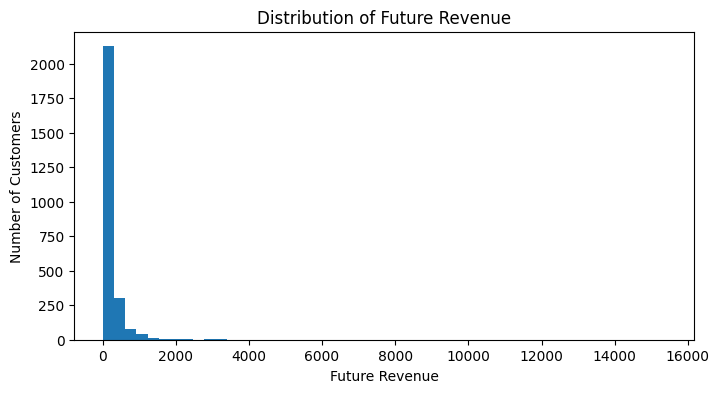

In [38]:
plt.figure(figsize=(8,4))
plt.hist(clv_data['FutureRevenue'],bins=50)
plt.title("Distribution of Future Revenue")
plt.xlabel("Future Revenue")
plt.ylabel("Number of Customers")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\clv_target_distribution.png")

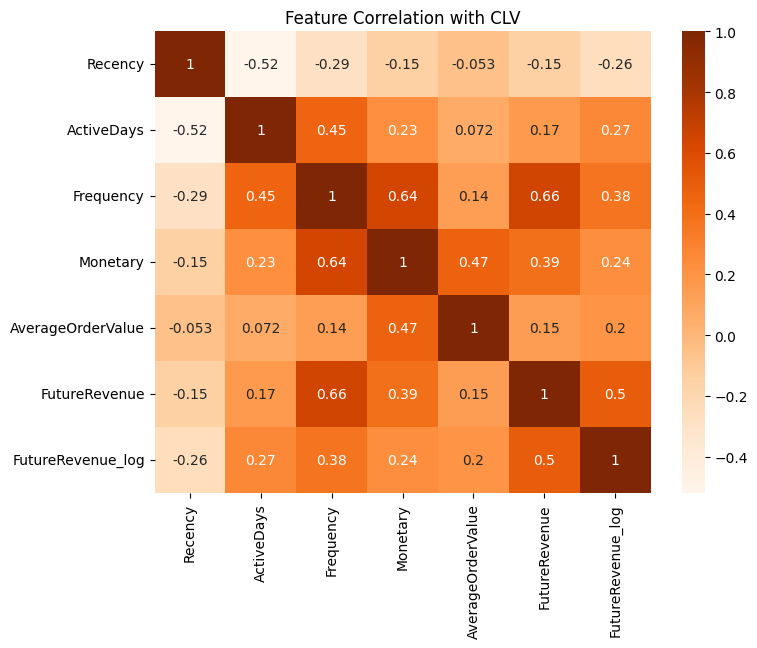

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(clv_data.drop(columns=['CustomerID']).corr(),annot=True,cmap="Oranges")
plt.title("Feature Correlation with CLV")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\clv_feature_correlation.png")

Frequency and Monetary show multicollinearity, meaning they share similar information

In [41]:
clv_data.sort_values("FutureRevenue",ascending=False).head(10)

,CustomerID,Recency,ActiveDays,Frequency,Monetary,AverageOrderValue,FutureRevenue
1098,14911.0,2,555,263,195537.25,743.487643,15409.66
2398,17841.0,2,554,137,42758.96,312.109197,13674.55
178,12748.0,1,552,219,32897.91,150.218767,8007.27
176,12744.0,68,342,8,14300.42,1787.552500,6467.88
1354,15502.0,94,279,6,6249.00,1041.500000,3877.08
958,14606.0,2,553,150,25810.44,172.069600,3289.36
975,14646.0,11,545,105,364532.42,3471.737333,3281.07
754,14156.0,5,552,120,241432.09,2011.934083,3172.16
1388,15581.0,45,511,33,4749.58,143.926667,3041.61
920,14527.0,3,553,94,22845.84,243.040851,2920.43


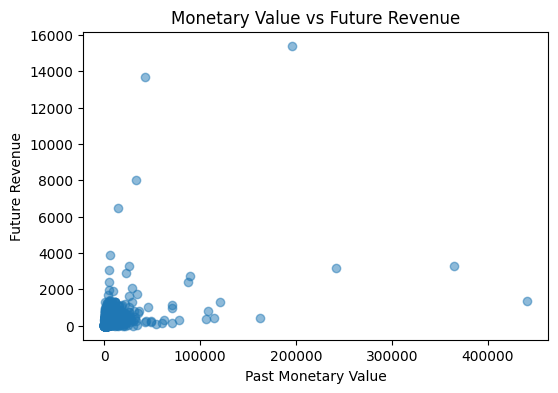

In [58]:
plt.figure(figsize=(6,4))
plt.scatter(clv_data['Monetary'],clv_data['FutureRevenue'],alpha=0.5)
plt.title("Monetary Value vs Future Revenue")
plt.xlabel("Past Monetary Value")
plt.ylabel("Future Revenue")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\monetary_vs_clv.png")

target variable is highly skewed -> Correlation values become misleading because Extreme high-value customers dominate calculations.

In [46]:
clv_data['FutureRevenue_log'] = np.log1p(clv_data['FutureRevenue'])

In [53]:
clv_data.head()

,CustomerID,Recency,ActiveDays,Frequency,Monetary,AverageOrderValue,FutureRevenue,FutureRevenue_log
0,12347.0,2,220,5,3529.27,705.854,202.54,5.315863
1,12348.0,68,189,4,1709.40,427.350,42.50,3.772761
2,12349.0,227,181,3,2671.14,890.380,605.10,6.407045
3,12352.0,81,130,7,1905.61,272.230,311.03,5.743099
4,12356.0,64,179,5,6315.33,1263.066,23.70,3.206803


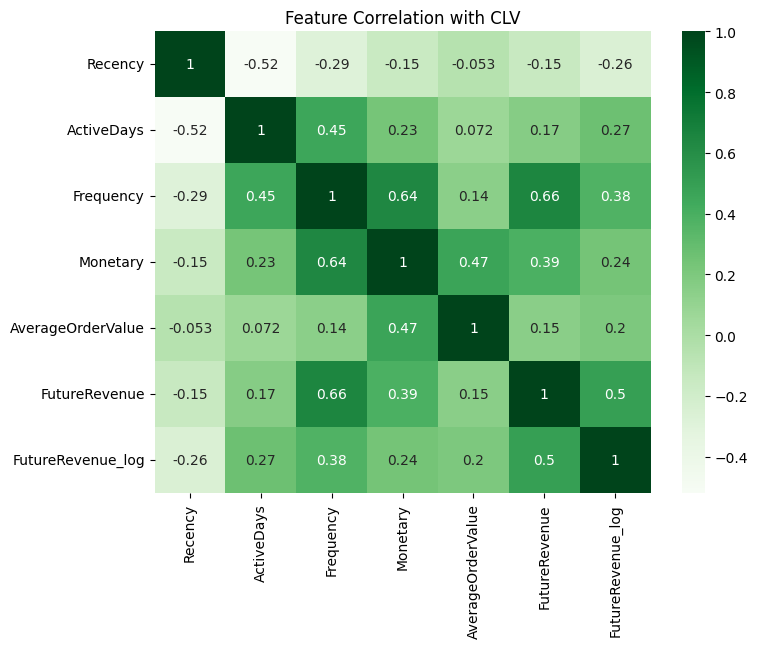

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(clv_data.drop(columns=['CustomerID']).corr(),annot=True,cmap="Greens")
plt.title("Feature Correlation with CLV")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\clv_feature_correlation_log.png")

Before transformation:
Few extreme customers dominated revenue.
Correlation was inflated by outliers

After log:
Extreme values compressed.
Relationship reflects overall population, not just top spenders

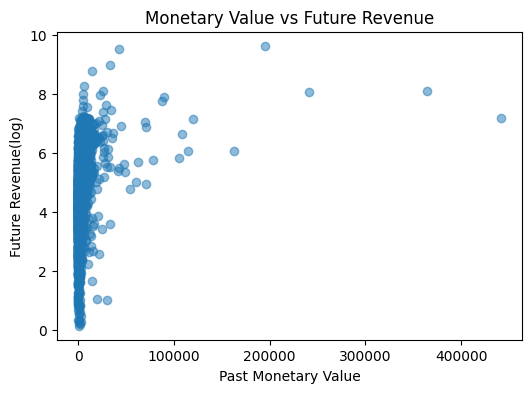

In [62]:
plt.figure(figsize=(6,4))
plt.scatter(clv_data['Monetary'],clv_data['FutureRevenue_log'],alpha=0.5)
plt.title("Monetary Value vs Future Revenue")
plt.xlabel("Past Monetary Value")
plt.ylabel("Future Revenue(log)")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\monetary_vs_clv_log.png")

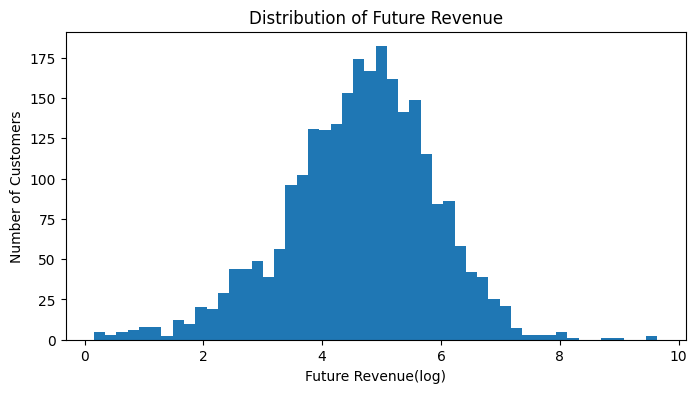

In [61]:
plt.figure(figsize=(8,4))
plt.hist(clv_data['FutureRevenue_log'],bins=50)
plt.title("Distribution of Future Revenue")
plt.xlabel("Future Revenue(log)")
plt.ylabel("Number of Customers")

plt.savefig(r"E:\SEM 8\Sales_Intelligence_System\Code_Implementation\Online_retail\clv_target_distribution_log.png")